# Независимый анализ сохранённых CSV
Дополнительное задание 4. Здесь нет вызова simulate или sir_run:
анализируется ранее записанный базовый опыт. Имя CSV включает параметры
и seed, поэтому разные эксперименты не перезаписывают друг друга.

In [1]:
using DrWatson
@quickactivate "project"
using project.SIRDES
using CSV, DataFrames, Statistics, StatsPlots
include(srcdir("experiments.jl"))
using .Experiments

In [2]:
index=CSV.read(datadir("analysis","baseline.csv"),DataFrame)
trajectory=CSV.read(projectdir(index.csv[1]),DataFrame)
@assert issorted(trajectory.t)
@assert all(trajectory.S+trajectory.I+trajectory.R .== 1000)
measured=trajectory_metrics(trajectory)
for key in keys(measured)
    @assert isapprox(measured[key],index[1,key];atol=1e-9)
end
summary=save_table("csv-validation",DataFrame([measured]))
display(summary)

Row,peak_I,peak_time,S_T,E_T,I_T,R_T,R_fraction,ever_infected
,Int64,Float64,Int64,Int64,Int64,Int64,Float64,Int64
1,174,17.8722,226,0,23,751,0.751,774


## Число переходов и баланс

In [3]:
counts=combine(groupby(trajectory,:event),nrow=>:count)
display(counts)
@assert last(trajectory.infections)==count(==("infection"),trajectory.event)

Row,event,count
,String15,Int64
1,initial,1
2,infection,764
3,recovery,751
4,horizon,1


## Событийные времена и регулярная сетка
Ступенчатая интерполяция берёт последнюю запись с t_event≤t.
Линейная интерполяция целочисленных состояний не используется.

Row,t,S,I,R
,Float64,Int64,Int64,Int64
1,0.0,990,10,0
2,0.5,987,11,2
3,1.0,981,16,3
4,1.5,978,15,7
5,2.0,975,16,9
6,2.5,966,23,11
7,3.0,961,23,16
8,3.5,956,24,20
9,4.0,946,30,24


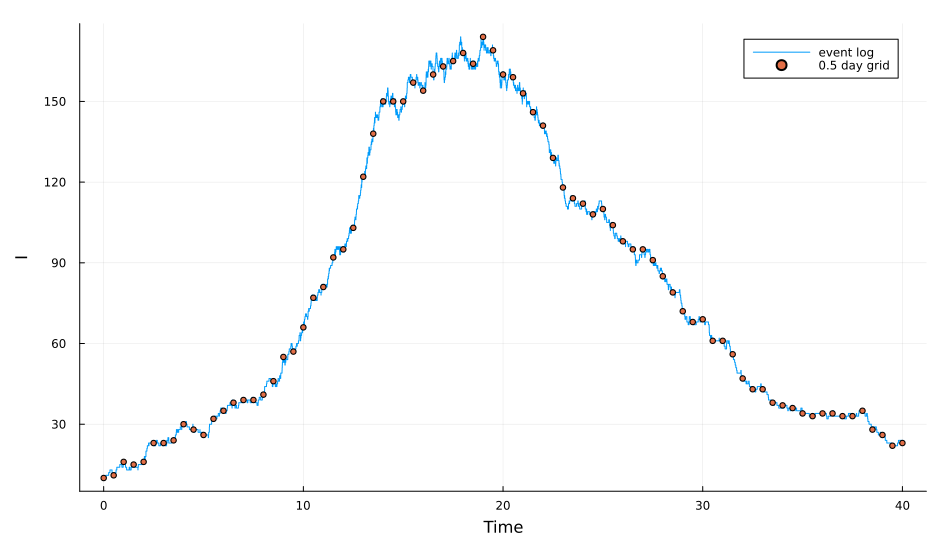

In [4]:
grid=collect(0.0:.5:40.0)
grid_data=save_table("baseline-grid",DataFrame(t=grid,
    S=sample_step(trajectory,grid,:S),I=sample_step(trajectory,grid,:I),
    R=sample_step(trajectory,grid,:R)))
display(first(grid_data,10))
fig=plot(trajectory.t,trajectory.I;seriestype=:steppost,label="event log",
    xlabel="Time",ylabel="I",size=(950,550))
scatter!(fig,grid,grid_data.I;label="0.5 day grid",markersize=3)
savefig(fig,figure_path("07-plot"))
display(fig)